# Vectorless RAG with PageIndex and Groq

This notebook demonstrates how to build a Retrieval-Augmented Generation (RAG) system using PageIndex's vectorless retrieval approach and Groq-hosted Large Language Models.

![image.png](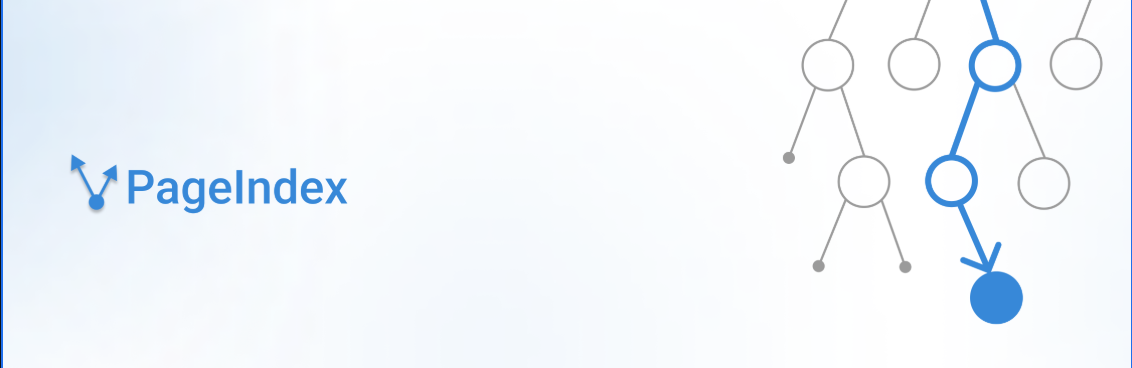 )

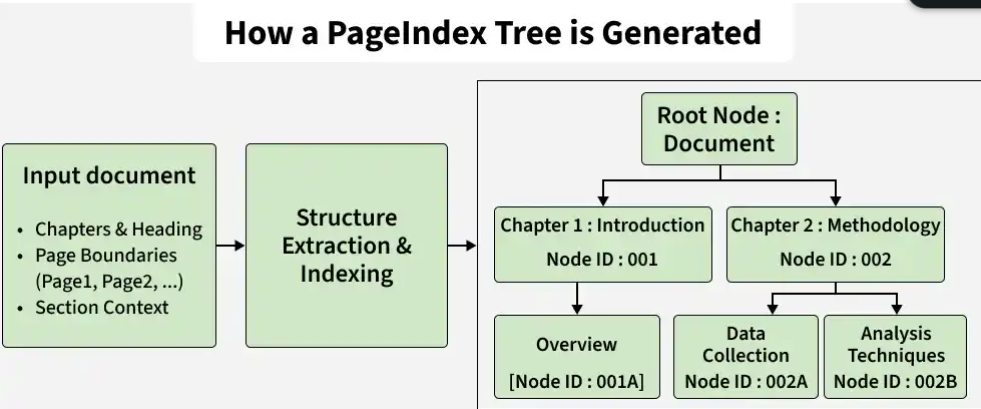

In [ ]:
!pip install pageindex
!pip install groq
!pip install langchain_groq


In [ ]:
import os
import json
import requests
import asyncio
from pageindex import PageIndexClient
import pageindex.utils as utils
from langchain_groq import ChatGroq


In [ ]:
GROQ_API_KEY="YOUR KEY HERE"

llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0.3,
    api_key=GROQ_API_KEY
)

response = llm.invoke("Hi")

print(response.content)

Hi! How are you today? Is there something I can help you with or would you like to chat?


In [ ]:
PAGEINDEX_API_KEY= "YOUR KEY HERE"
pi_client = PageIndexClient(api_key=PAGEINDEX_API_KEY)

In [ ]:
pdf_url = "https://arxiv.org/pdf/2501.12948.pdf"
pdf_path = os.path.join("../data", pdf_url.split('/')[-1])
os.makedirs(os.path.dirname(pdf_path), exist_ok=True)

In [ ]:
response = requests.get(pdf_url)
with open(pdf_path, "wb") as f:
    f.write(response.content)
print(f"Downloaded {pdf_url}")

Downloaded https://arxiv.org/pdf/2501.12948.pdf


In [ ]:
doc_info = pi_client.submit_document(pdf_path)
doc_id = doc_info["doc_id"]
print('Document Submitted:', doc_id)

Document Submitted: pi-cmpzij0vz000l01qxhj0icqqu


In [ ]:
import time
print(f"Waiting for document {doc_id} to be indexed...")
max_retries = 30
retry_count = 0

while not pi_client.is_retrieval_ready(doc_id):
    if retry_count >= max_retries:
        print("Timeout: Document processing took too long.")
        break

    print(f"Still processing... (Attempt {retry_count + 1}/{max_retries})")
    time.sleep(5)
    retry_count += 1
if pi_client.is_retrieval_ready(doc_id):
    print("Success! Document is ready.")
    tree = pi_client.get_tree(doc_id, node_summary=True)['result']
    print('Simplified Tree Structure of the Document:')
    utils.print_tree(tree)
else:
    tree = None

Waiting for document pi-cmpzij0vz000l01qxhj0icqqu to be indexed...
Still processing... (Attempt 1/30)
Still processing... (Attempt 2/30)
Still processing... (Attempt 3/30)
Still processing... (Attempt 4/30)
Still processing... (Attempt 5/30)
Still processing... (Attempt 6/30)
Still processing... (Attempt 7/30)
Still processing... (Attempt 8/30)
Still processing... (Attempt 9/30)
Still processing... (Attempt 10/30)
Still processing... (Attempt 11/30)
Still processing... (Attempt 12/30)
Success! Document is ready.
Simplified Tree Structure of the Document:
[{'title': 'Abstract', 'node_id': '0000', 'summary': 'This text introduces a reinforcement lea...'},
 {'title': '1 Introduction',
  'node_id': '0001',
  'summary': 'The text discusses the evolution of reas...'},
 {'title': '2 DeepSeek-R1-Zero',
  'node_id': '0002',
  'summary': 'This text details the development of Dee...'},
 {'title': '3. DeepSeek-R1',
  'node_id': '0003',
  'summary': 'This text details the development of Dee...'},
 

In [ ]:
def retrieve_from_pageindex(query, doc_id, top_k=3):

    # Submit query
    response = pi_client.submit_query(
        doc_id=doc_id,
        query=query
    )

    retrieval_id = response.get("retrieval_id")
    if not retrieval_id:
        return []

    # Poll until retrieval is complete
    while True:
        retrieval = pi_client.get_retrieval(retrieval_id)
        status = retrieval.get("status")

        if status == "completed":
            break
        elif status == "failed":
            return []

        time.sleep(1)

    nodes = retrieval.get("retrieved_nodes", [])
    contexts = []

    for node in nodes[:top_k]:
        relevant_contents = node.get("relevant_contents", [])

        for group in relevant_contents:
            for item in group:
                content = item.get("relevant_content")
                if content:
                    contexts.append(content)

    return contexts


In [ ]:
def vectorless_rag(query, doc_id):

    contexts = retrieve_from_pageindex(query, doc_id)

    if not contexts:
        return "No relevant context found."

    combined_context = "\n\n".join(contexts)

    prompt = f"""
    You are a research assistant.
    Answer ONLY using the context below.
    If the answer is not found, say "Not found in document."

    Context:
    {combined_context}

    Question:
    {query}
    """

    response = llm.invoke(prompt)

    return response.content


In [ ]:
query = "What is the main contribution of this paper?"

answer = vectorless_rag(query, doc_id)

print("\nFINAL ANSWER:\n")
print(answer)



FINAL ANSWER:

The paper's main contribution is demonstrating that the reasoning abilities of large language models (LLMs) can be enhanced through pure reinforcement learning (RL) without the need for human-labeled reasoning trajectories.


In [ ]:
query ="According to the graph, approximately how many average thinking tokens are used when the problem difficulty is 0.5?"

answer = vectorless_rag(query, doc_id)

print("\nFINAL ANSWER:\n")
print(answer)



FINAL ANSWER:

According to Figure 18, when the problem difficulty is 0.5, the average thinking tokens used is approximately 8,000. 

Alternatively, Figure 1(b) indicates that when the problem difficulty is approximately 0.5, the average thinking tokens used is about 400 tokens for DeepSeek-R1-Zero on the training set.


In [ ]:
query ="What is the MATH pass@1 score of Qwen2.5-32B-Zero in figure given?"

answer = vectorless_rag(query, doc_id)

print("\nFINAL ANSWER:\n")
print(answer)



FINAL ANSWER:

91.6


   ![image.png](
   
   
   
   
   
   
   
   
   ...)